# Phase 2: Huấn luyện và mô phỏng World Cup 2026

Notebook này đánh giá model theo thời gian, refit bằng toàn bộ trận đã đá, rồi mô phỏng vòng bảng bằng tỷ số để có thể xử lý tie-break.

In [1]:
from collections import defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("src").resolve()))

from wc2026_predictor.config import FINAL_FEATURES, FORM_FEATURES
from wc2026_predictor.modeling import (
    baseline_scores,
    calibration_table,
    classifier_classes,
    evaluate_classifier_candidates,
    evaluate_goal_models,
    fit_goal_models,
    fit_outcome_model,
    predict_goal_rates as model_predict_goal_rates,
    predict_outcome_probabilities,
    recency_weights,
)
from wc2026_predictor.simulation import calculate_table, rank_group

df_recent = pd.read_csv("data/processed/matches_features.csv", parse_dates=["date"])
upcoming_matches = pd.read_csv("data/processed/upcoming_matches.csv", parse_dates=["date"])

assert df_recent["outcome"].notna().all()
assert upcoming_matches["outcome"].isna().all()
assert df_recent.duplicated().sum() == 0

print("Tr?n ?? ??:", df_recent.shape)
print("Tr?n ch?a ??:", upcoming_matches.shape)

Tr?n ?? ??: (10784, 19)
Tr?n ch?a ??: (32, 19)


## Đánh giá model theo thời gian

Các trận trước năm 2024 dùng để train; các trận từ năm 2024 trở đi dùng để test. Elo của mỗi dòng đã được ghi **trước trận**, nên phép đánh giá tương ứng với dự báo tuần tự theo thời gian.

In [2]:
CUTOFF_DATE = pd.Timestamp("2024-01-01")
train = df_recent[df_recent["date"].lt(CUTOFF_DATE)].copy()
test = df_recent[df_recent["date"].ge(CUTOFF_DATE)].copy()

print("Train:", train.shape)
print("Test:", test.shape)

train_weights = recency_weights(train["date"])
full_weights = recency_weights(df_recent["date"])

Train: (8872, 19)
Test: (1912, 19)


In [3]:
candidate_features = {
    "elo_only": ["elo_diff"],
    "elo_and_neutral": ["elo_diff", "neutral"],
    "elo_neutral_and_form": FINAL_FEATURES,
}

subsets = {
    "all_test": pd.Series(True, index=test.index),
    "neutral_test": test["neutral"].eq(True),
    "world_cup_test": test["tournament"].eq("FIFA World Cup"),
}

evaluation, validation_models = evaluate_classifier_candidates(
    train,
    test,
    candidate_features,
    subsets,
)
evaluation

,model,subset,n_matches,accuracy,log_loss,brier_score
0,elo_only,all_test,1912,0.595711,0.879457,0.516826
1,elo_only,neutral_test,700,0.537143,0.964931,0.573593
2,elo_only,world_cup_test,40,0.475000,1.003245,0.606377
3,elo_and_neutral,all_test,1912,0.592050,0.879692,0.517199
4,elo_and_neutral,neutral_test,700,0.540000,0.964542,0.573696
5,elo_and_neutral,world_cup_test,40,0.500000,1.001096,0.603892
6,elo_neutral_and_form,all_test,1912,0.596234,0.871229,0.511442
7,elo_neutral_and_form,neutral_test,700,0.552857,0.944149,0.560277
8,elo_neutral_and_form,world_cup_test,40,0.500000,0.976585,0.589013


In [4]:
baseline = baseline_scores(train, test)
print("Baseline accuracy:", round(baseline["accuracy"], 3))
print("Baseline log loss:", round(baseline["log_loss"], 3))
print("Baseline Brier score:", round(baseline["brier_score"], 3))

Baseline accuracy: 0.468
Baseline log loss: 1.057
Baseline Brier score: 0.638


## Calibration check

Brier score and calibration bins show whether probabilities are usable as probabilities, not only as class labels.

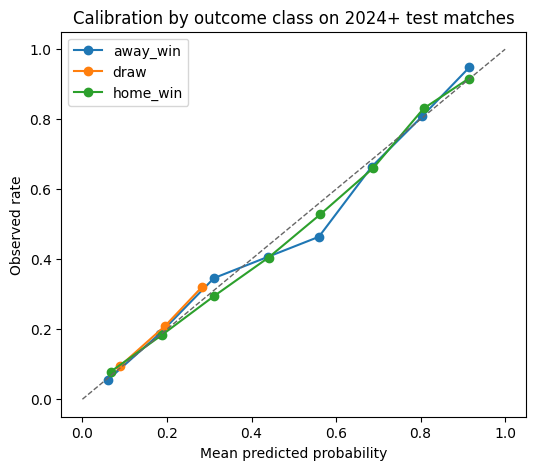

,class,bin_low,bin_high,n,mean_predicted,observed_rate
0,away_win,0.000,0.125,568,0.059596,0.054577
1,away_win,0.125,0.250,422,0.182695,0.187204
2,away_win,0.250,0.375,263,0.311114,0.346008
3,away_win,0.375,0.500,214,0.438245,0.406542
4,away_win,0.500,0.625,181,0.559355,0.464088
5,away_win,0.625,0.750,131,0.684257,0.664122
6,away_win,0.750,0.875,94,0.803949,0.808511
7,away_win,0.875,1.000,39,0.915675,0.948718
8,draw,0.000,0.125,235,0.087856,0.093617
9,draw,0.125,0.250,1031,0.195578,0.209505


In [5]:
best_model_name = "elo_neutral_and_form"
best_features = candidate_features[best_model_name]
best_model = validation_models[best_model_name]
classes = classifier_classes(best_model)
test_probabilities = best_model.predict_proba(test[best_features])
calibration = calibration_table(test["outcome"], test_probabilities, classes, n_bins=8)

fig, ax = plt.subplots(figsize=(6, 5))
for outcome in classes:
    subset = calibration[calibration["class"].eq(outcome)]
    ax.plot(
        subset["mean_predicted"],
        subset["observed_rate"],
        marker="o",
        linewidth=1.5,
        label=outcome,
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="#666666", linewidth=1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed rate")
ax.set_title("Calibration by outcome class on 2024+ test matches")
ax.legend(frameon=True)
plt.show()

calibration.head(12)

## Model phân loại cuối cùng

Model cuối giữ `neutral` và form 5 trận gần nhất vì chúng cải thiện log loss trên tập test theo thời gian, đặc biệt ở sân trung lập. Dữ liệu cũ được giảm trọng số với half-life 4 năm. Sau khi đánh giá, model được refit bằng **toàn bộ trận đã đá**.

In [6]:
final_model = fit_outcome_model(df_recent, FINAL_FEATURES)

## Model tỷ số cho Monte Carlo

Logistic Regression chỉ tạo kết quả thắng/hòa/thua nên không đủ để xếp hạng khi bằng điểm. Hai Poisson Regression dưới đây dự đoán số bàn của đội nhà và đội khách; nhờ đó mô phỏng có thể tính hiệu số và bàn thắng.

In [7]:
GOAL_FEATURES = FINAL_FEATURES

goal_metrics = evaluate_goal_models(train, test, GOAL_FEATURES)
print("MAE b?n ??i nh?:", round(goal_metrics["home_mae"], 3))
print("MAE b?n ??i kh?ch:", round(goal_metrics["away_mae"], 3))

home_goal_model, away_goal_model = fit_goal_models(df_recent, GOAL_FEATURES)

MAE b?n ??i nh?: 1.059
MAE b?n ??i kh?ch: 0.882


C:\Users\khanh\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\khanh\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [8]:
wc_played_all = df_recent[
    df_recent["tournament"].eq("FIFA World Cup")
    & df_recent["date"].ge("2026-01-01")
].copy()
wc_upcoming_all = upcoming_matches[
    upcoming_matches["tournament"].eq("FIFA World Cup")
].copy()

# 72 trận đầu tiên của World Cup 2026 là vòng bảng.
wc_group_matches = (
    pd.concat([wc_played_all, wc_upcoming_all], ignore_index=True, sort=False)
    .sort_values(["date", "home_team", "away_team"])
    .head(72)
    .reset_index(drop=True)
)
wc2026_played = wc_group_matches.dropna(subset=["home_score", "away_score"]).copy()
wc2026_upcoming = wc_group_matches[
    wc_group_matches[["home_score", "away_score"]].isna().any(axis=1)
].copy()

assert len(wc_group_matches) == 72
assert wc2026_upcoming["tournament"].eq("FIFA World Cup").all()
print("Đã đá:", len(wc2026_played), "| Chưa đá:", len(wc2026_upcoming))

Đã đá: 40 | Chưa đá: 32


In [9]:
opponents = defaultdict(set)
for row in wc_group_matches.itertuples(index=False):
    opponents[row.home_team].add(row.away_team)
    opponents[row.away_team].add(row.home_team)

unvisited = set(opponents)
groups = []
while unvisited:
    start = unvisited.pop()
    component = {start}
    stack = [start]
    while stack:
        team = stack.pop()
        new_teams = opponents[team] - component
        component.update(new_teams)
        unvisited.difference_update(new_teams)
        stack.extend(new_teams)
    groups.append(tuple(sorted(component)))

groups = sorted(groups, key=lambda group: group[0])
assert len(groups) == 12 and all(len(group) == 4 for group in groups)
for number, group in enumerate(groups, start=1):
    print(number, group)

1 ('Algeria', 'Argentina', 'Austria', 'Jordan')
2 ('Australia', 'Paraguay', 'Turkey', 'United States')
3 ('Belgium', 'Egypt', 'Iran', 'New Zealand')
4 ('Bosnia and Herzegovina', 'Canada', 'Qatar', 'Switzerland')
5 ('Brazil', 'Haiti', 'Morocco', 'Scotland')
6 ('Cape Verde', 'Saudi Arabia', 'Spain', 'Uruguay')
7 ('Colombia', 'DR Congo', 'Portugal', 'Uzbekistan')
8 ('Croatia', 'England', 'Ghana', 'Panama')
9 ('Curaçao', 'Ecuador', 'Germany', 'Ivory Coast')
10 ('Czech Republic', 'Mexico', 'South Africa', 'South Korea')
11 ('France', 'Iraq', 'Norway', 'Senegal')
12 ('Japan', 'Netherlands', 'Sweden', 'Tunisia')


In [10]:
def predict_goal_rates(row):
    return model_predict_goal_rates(home_goal_model, away_goal_model, row, GOAL_FEATURES)


goal_rates = wc2026_upcoming.apply(predict_goal_rates, axis=1, result_type="expand")
goal_rates.columns = ["home_goal_rate", "away_goal_rate"]
wc2026_upcoming = pd.concat(
    [wc2026_upcoming.reset_index(drop=True), goal_rates.reset_index(drop=True)],
    axis=1,
)

probability_rows = []
for _, row in wc2026_upcoming.iterrows():
    probability_rows.append({
        "date": row["date"],
        "home_team": row["home_team"],
        "away_team": row["away_team"],
        **predict_outcome_probabilities(final_model, row),
    })
match_probabilities = pd.DataFrame(probability_rows)
match_probabilities.head()

,date,home_team,away_team,away_win,draw,home_win
0,2026-06-22,Argentina,Austria,0.115453,0.234359,0.650188
1,2026-06-22,France,Iraq,0.097639,0.207114,0.695246
2,2026-06-22,Jordan,Algeria,0.309979,0.305060,0.384961
3,2026-06-22,Norway,Senegal,0.356256,0.276397,0.367347
4,2026-06-23,Colombia,DR Congo,0.257590,0.307909,0.434501


## Xếp hạng và tie-break

Thứ tự được xét theo điểm, hiệu số và bàn thắng; nếu vẫn bằng nhau thì xét thành tích đối đầu giữa các đội đang hòa. Dữ liệu không có điểm fair-play, nên trường hợp vẫn hòa tuyệt đối được xử lý bằng bốc thăm có seed thay vì phụ thuộc vào thứ tự ngẫu nhiên của `set`.

In [11]:
# Group ranking helpers are imported from wc2026_predictor.simulation.
# They are kept in src/ so scripts, tests, and notebooks all use the same tie-break behavior.

In [12]:
group_data = []
for group in groups:
    played = wc2026_played[
        wc2026_played["home_team"].isin(group)
        & wc2026_played["away_team"].isin(group)
    ]
    future = wc2026_upcoming[
        wc2026_upcoming["home_team"].isin(group)
        & wc2026_upcoming["away_team"].isin(group)
    ]
    played_results = [
        (row.home_team, row.away_team, int(row.home_score), int(row.away_score))
        for row in played.itertuples(index=False)
    ]
    future_matches = [
        (row.home_team, row.away_team, row.home_goal_rate, row.away_goal_rate)
        for row in future.itertuples(index=False)
    ]
    group_data.append({"teams": group, "played": played_results, "future": future_matches})

assert sum(len(item["played"]) + len(item["future"]) for item in group_data) == 72

In [13]:
def simulate_group(group_info, rng):
    results = list(group_info["played"])
    for home, away, home_rate, away_rate in group_info["future"]:
        home_goals = int(rng.poisson(home_rate))
        away_goals = int(rng.poisson(away_rate))
        results.append((home, away, home_goals, away_goals))
    return rank_group(group_info["teams"], results, rng)


def run_group_stage(group_data, rng):
    standings = [simulate_group(group_info, rng) for group_info in group_data]
    first_place = [table[0]["team"] for table in standings]
    second_place = [table[1]["team"] for table in standings]
    third_place = [table[2] for table in standings]

    third_lottery = {row["team"]: rng.random() for row in third_place}
    third_place.sort(
        key=lambda row: (row["points"], row["gd"], row["gf"], third_lottery[row["team"]]),
        reverse=True,
    )
    qualified = set(first_place + second_place + [row["team"] for row in third_place[:8]])
    assert len(qualified) == 32
    return qualified

In [14]:
N_SIMULATIONS = 10_000
rng = np.random.default_rng(42)
advance_count = {team: 0 for group in groups for team in group}

for _ in range(N_SIMULATIONS):
    for team in run_group_stage(group_data, rng):
        advance_count[team] += 1

advance_probabilities = (
    pd.DataFrame({
        "team": list(advance_count),
        "advance_probability": [count / N_SIMULATIONS for count in advance_count.values()],
    })
    .sort_values("advance_probability", ascending=False)
    .reset_index(drop=True)
)
advance_probabilities

,team,advance_probability
0,United States,1.0000
1,Switzerland,1.0000
2,Canada,1.0000
3,Egypt,1.0000
4,Germany,1.0000
5,Spain,1.0000
6,Morocco,1.0000
7,Brazil,1.0000
8,Japan,1.0000
9,Mexico,1.0000


## Giới hạn còn lại

Đây vẫn là model gọn: số bàn của hai đội được mô phỏng độc lập, chưa có chấn thương/đội hình và dữ liệu không có điểm fair-play. Tuy vậy, kết quả không còn bị quyết định bởi thứ tự của `set`, trận chưa đá không bị coi là hòa, và model triển khai đã được refit bằng toàn bộ dữ liệu đã biết.